In [7]:
import pandas as pd
from sklearn.ensemble import IsolationForest

In [8]:
# Load data
df = pd.read_csv("./biometric.csv")

# Remove bad states
bad_values = [
    "Darbhanga", "Puttenahalli", "Balanagar", "Jaipur",
    "Madanapalle", "Nagpur", "Raja Annamalai Puram", "100000","BALANAGAR"
]
df = df[~df["state"].isin(bad_values)]

# Standardize state names (optional, same as before)
state_mapping = {
    "west Bengal": "West Bengal", "West  Bengal": "West Bengal", "Westbengal": "West Bengal",
    "WEST BENGAL": "West Bengal", "West Bangal": "West Bengal", "West bengal": "West Bengal",
    "WESTBENGAL": "West Bengal", "West Bengli": "West Bengal",
    "odisha": "Odisha", "ODISHA": "Odisha", "Orissa": "Odisha",
}
df['state'] = df['state'].replace(state_mapping)

# Drop duplicates
df = df.drop_duplicates()

# Aggregate duplicate pincode-date rows
df = df.groupby(["pincode", "date"], as_index=False).agg({
    "state": "first",
    "bio_age_5_17": "sum",
    "bio_age_17_": "sum"
})

# Total enrollment
df["total_enrollment"] = df["bio_age_5_17"] + df["bio_age_17_"]


In [9]:
df = df.sort_values(["pincode", "date"])

df["rolling_mean"] = df.groupby("pincode")["total_enrollment"] \
    .transform(lambda x: x.rolling(7, min_periods=1).mean())

df["rolling_std"] = df.groupby("pincode")["total_enrollment"] \
    .transform(lambda x: x.rolling(7, min_periods=1).std())

df["delta"] = df["total_enrollment"] - df["rolling_mean"]


In [10]:
from sklearn.ensemble import IsolationForest

features = df[["total_enrollment", "delta"]].fillna(0)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

df["iso_anomaly"] = iso.fit_predict(features)
df["iso_anomaly"] = (df["iso_anomaly"] == -1).astype(int)

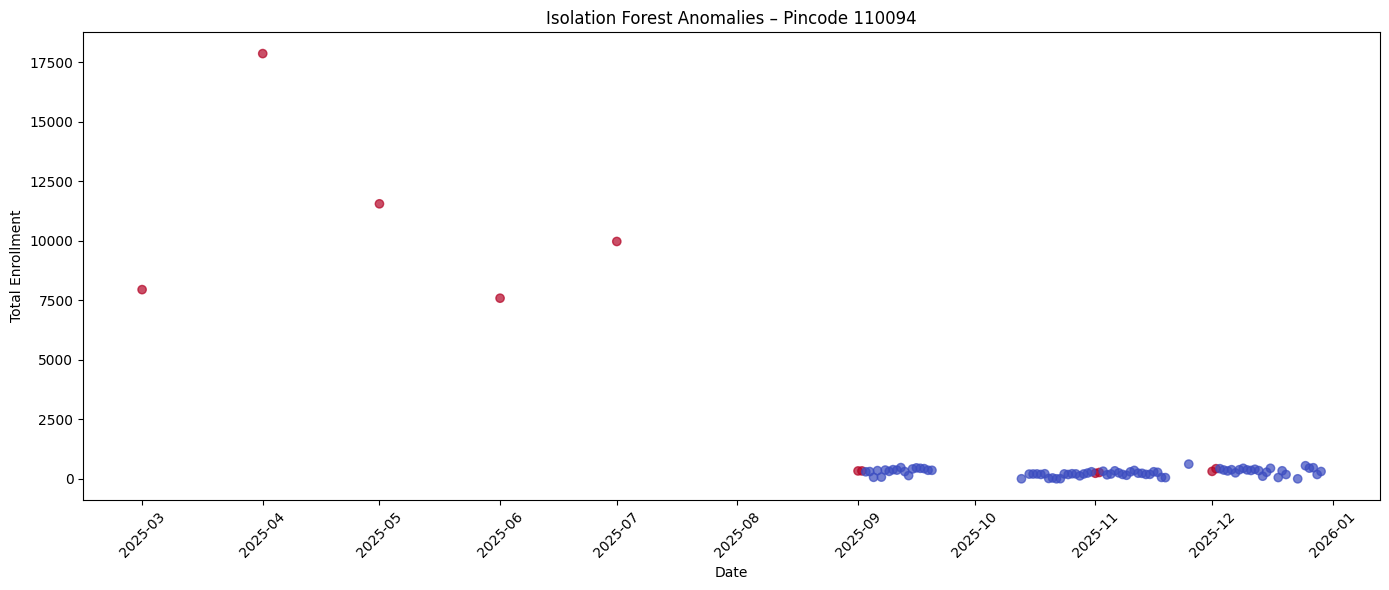

In [13]:
import matplotlib.pylab as plt
df["date"] = pd.to_datetime(df["date"],format = "%d-%m-%Y")

sample_pin = df["pincode"].value_counts().idxmax()
temp = df[df["pincode"] == sample_pin]

plt.figure(figsize=(14,6))
plt.scatter(
    temp["date"],
    temp["total_enrollment"],
    c=temp["iso_anomaly"],
    cmap="coolwarm",
    alpha=0.7
)
plt.xticks(rotation=45)
plt.title(f"Isolation Forest Anomalies – Pincode {sample_pin}")
plt.xlabel("Date")
plt.ylabel("Total Enrollment")
plt.tight_layout()
plt.show()

